# Modèle gaussien, frontière LDA / QDA

Le [2.3b](2.3b-Naive-Bayes-Generatif.ipynb) faisait le pont génératif-discriminatif sous l'hypothèse d'**indépendance** des variables (Naive Bayes, covariance diagonale). Ici on relâche cette hypothèse et on regarde ce que devient la **frontière de décision** quand la covariance est complète.

- **LDA** (Linear Discriminant Analysis) : les classes partagent la **même covariance** `Σ`. La frontière est **linéaire**.
- **QDA** (Quadratic Discriminant Analysis) : chaque classe a sa **propre covariance** `Σ_c`. La frontière est **quadratique**.

Le point pédagogique : **l'hypothèse de covariance** n'est pas un détail technique — c'est elle qui décide si la frontière est droite ou courbe, et le bon modèle est celui dont l'hypothèse colle aux données.

> **Fil conducteur.** On dérive la frontière depuis la log-densité gaussienne, on implémente le LDA de zéro et on le vérifie contre `sklearn`, puis on construit **trois régimes contrôlés** où l'hypothèse de covariance change. On mesure lequel de LDA / QDA / logistique / Naive Bayes gagne dans chaque régime — c'est la **signature** d'une hypothèse, pas une course d'accuracy. Enfin on regarde le coût de QDA en grande dimension (où `Σ_c` devient singulière).

> **Note.** Ici *LDA* = **Linear Discriminant Analysis**. L'autre « LDA » (Latent Dirichlet Allocation) est déjà enseignée en topic modeling — hors sujet ici.


In [1]:
# Imports et configuration (meme style que la serie)
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (6, 4)


### 1. Du modèle gaussien à la frontière

On suppose `P(x|c)` gaussien. La log-densité de la classe `c` est :

$$\log P(x|c) = -\tfrac{d}{2}\log(2\pi) - \tfrac{1}{2}\log|\Sigma_c| - \tfrac{1}{2}(x-\mu_c)^\top \Sigma_c^{-1}(x-\mu_c)$$

Le postérieur s'écrit `log P(c|x) ∝ log P(x|c) + log π_c`. La **frontière** entre deux classes `k` et `l` est l'ensemble où `log P(k|x) = log P(l|x)` :

$$-\tfrac{1}{2}\log|\Sigma_k| - \tfrac{1}{2}(x-\mu_k)^\top \Sigma_k^{-1}(x-\mu_k) + \log\pi_k = -\tfrac{1}{2}\log|\Sigma_l| - \tfrac{1}{2}(x-\mu_l)^\top \Sigma_l^{-1}(x-\mu_l) + \log\pi_l$$

Deux cas décisifs :

- **`Σ_k = Σ_l = Σ`** (covariance partagée, **LDA**) : les termes `-1/2 log|Σ|` s'annulent, et le terme quadratique `x^⊤Σ^{-1}x` **présent des deux côtés s'élimine**. Il ne reste qu'une expression **linéaire** en `x` :

$$(\mu_k-\mu_l)^\top \Sigma^{-1} x - \tfrac{1}{2}(\mu_k^\top\Sigma^{-1}\mu_k - \mu_l^\top\Sigma^{-1}\mu_l) + \log\tfrac{\pi_k}{\pi_l} = 0$$

  La frontière est donc un **hyperplan** : direction `w = Σ^{-1}(μ_k - μ_l)`, offset `b = -1/2(μ_k^⊤Σ^{-1}μ_k - μ_l^⊤Σ^{-1}μ_l) + log(π_k/π_l)`.

- **`Σ_k ≠ Σ_l`** (**QDA**) : le terme `-1/2 log|Σ_c|` ne s'annule pas et les termes `x^⊤Σ_c^{-1}x` **ne se simplifient pas** — on garde un **terme quadratique** `x^⊤(Σ_k^{-1}-Σ_l^{-1})x`. La frontière est une **conique** (quadratique).

**Le Naive Bayes de [2.3b](2.3b-Naive-Bayes-Generatif.ipynb)** est le cas particulier où chaque `Σ_c` est **diagonale** (indépendance) — une QDA *diagonalisée*, encore plus restrictive. On a donc un spectre : LDA (Σ partagée, frontière droite) → QDA (Σ propres, frontière courbe) → Naive Bayes (Σ diagonales, frontière courbe mais variables indépendantes).


In [2]:
# 2.1 LDA de zéro (2D) : covariance partagée + frontière linéaire
class MyLDA:
    def fit(self, X, y):
        self.classes = np.unique(y)
        k = len(self.classes)
        self.means = {c: X[y == c].mean(axis=0) for c in self.classes}
        # covariance POOLED (partagee entre classes) -> hypothese LDA
        diff = np.vstack([X[y == c] - self.means[c] for c in self.classes])
        self.cov = np.cov(diff, rowvar=False)
        self.cov_inv = np.linalg.inv(self.cov + 1e-9 * np.eye(X.shape[1]))
        n = {c: int((y == c).sum()) for c in self.classes}
        self.prior = {c: n[c] / len(y) for c in self.classes}
        return self

    def linear_discriminant(self, X):
        # score(x) = (mu_k - mu_l)^T Sigma^-1 x + b  pour CHAQUE classe (forme quadratique tronquee)
        # On calcule log P(c|x) en DROPPANT le terme x^T Sigma^-1 x (commun, disparait dans le LDA)
        scores = np.zeros((len(self.classes), len(X)))
        for i, c in enumerate(self.classes):
            m = self.means[c]
            # -1/2 (x-mu)^T Sigma^-1 (x-mu) + log prior ; on developpe pour extraire le lineaire
            scores[i] = -0.5 * np.einsum('ij,jk,ik->i', X - m, self.cov_inv, X - m)                         + np.log(self.prior[c])
        return scores

    def predict(self, X):
        return self.classes[np.argmax(self.linear_discriminant(X), axis=0)]


In [3]:
# 2.2 Vérification numérique contre sklearn LDA (solver lsqr, meme covariance empirique)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SKLDA
np.random.seed(0)
n, d = 200, 2
mu0, mu1 = np.array([-1.5, 0.0]), np.array([1.5, 0.0])
Sigma = np.array([[1.0, 0.6], [0.6, 1.0]])          # covariance PARTAGEE
X0 = np.random.multivariate_normal(mu0, Sigma, n)
X1 = np.random.multivariate_normal(mu1, Sigma, n)
X = np.vstack([X0, X1]); y = np.concatenate([np.zeros(n), np.ones(n)]).astype(int)

my = MyLDA().fit(X, y)
sk = SKLDA(solver="lsqr").fit(X, y)                  # lsqr = meme estimateur de covariance empirique

pred_my = my.predict(X); pred_sk = sk.predict(X)
acc_my = accuracy_score(y, pred_my); acc_sk = accuracy_score(y, pred_sk)
print("accuracy from-scratch", round(acc_my, 4), "| sklearn lsqr", round(acc_sk, 4),
      "| identiques:", bool(np.array_equal(pred_my, pred_sk)))
# la direction de la frontiere : w = Sigma^-1 (mu1 - mu0)
w_my = my.cov_inv @ (my.means[1] - my.means[0])
w_sk = sk.coef_[0]
print("w from-scratch", np.round(w_my, 3), "| w sklearn", np.round(w_sk, 3),
      "| cos(w_my, w_sk) =", round(float(np.dot(w_my, w_sk) / (np.linalg.norm(w_my) * np.linalg.norm(w_sk))), 4))
print("intercept from-scratch | sklearn", round(float(sk.intercept_[0]), 3))


accuracy from-scratch 0.98 | sklearn lsqr 0.98 | identiques: True
w from-scratch [ 4.877 -2.913] | w sklearn [ 4.889 -2.92 ] | cos(w_my, w_sk) = 1.0
intercept from-scratch | sklearn -0.358


### Lecture — la vérification vaut preuve

Le from-scratch reproduit `sklearn` **à l'identique sur les prédictions** (`accuracy` égale, `pred` identiques) dès qu'on utilise le même estimateur de covariance (`solver="lsqr"`). La **direction** `w = Σ^{-1}(μ_1-μ_0)` calculée à la main a un cosinus de `~1.0` avec le `coef_` de `sklearn` : le calcul de la section 1 se vérifie. Le from-scratch et `sklearn` donnent la **même accuracy (0.98)**, les **mêmes prédictions** (`identiques: True`), et la direction `w = Σ^{-1}(μ_1-μ_0)` calculée à la main a un **cosinus de 1.0** avec le `coef_` de `sklearn` (w = [4.877, −2.913] vs [4.889, −2.92] — l'écart est un bruit numérique). La frontière linéaire du §1 se vérifie : le LDA est exactement ce calcul, pas une boîte noire.


### 3. Trois régimes contrôlés — l'hypothèse de covariance décide

On construit trois jeux où **seule** l'hypothèse de covariance change, tout le reste (séparabilité, dimensions, tailles) étant tenu comparable :

- **Régime A — covariance partagée** : les deux classes sont tirées avec le **même** `Σ`. L'hypothèse LDA est **vraie** → la frontière linéaire est optimale.
- **Régime B — covariances propres** : `Σ_0` et `Σ_1` diffèrent (ici par le **signe de la corrélation**). L'hypothèse LDA est **fausse** → la frontière est courbe, QDA devrait gagner.
- **Régime C — petit échantillon mal conditionné** : même structure que B mais avec très peu de points et des classes proches. QDA doit estimer `Σ_k` et `Σ_l` séparément — en petit `n`, la **variance d'estimation** l'emporte.

On compare sur les **mêmes splits et graines** [2.3](2.3-Regression-lineaire-logistique.ipynb) : LDA, QDA, logistique (linéaire), Naive Bayes (gaussien diagonal).


In [4]:
# 3.1 Tirage + evaluation multi-graines (meme split reproductible, moyenne sur 20 graines)
def make_pair(n, mu0, mu1, S0, S1, seed):
    r = np.random.default_rng(seed)
    X0 = r.multivariate_normal(mu0, S0, n); X1 = r.multivariate_normal(mu1, S1, n)
    X = np.vstack([X0, X1]); y = np.concatenate([np.zeros(n), np.ones(n)]).astype(int)
    return X, y

muA0, muA1 = [-1.5, 0.0], [1.5, 0.0]
S_shared = [[1.0, 0.6], [0.6, 1.0]]
muB0, muB1 = [-1.0, 0.0], [1.0, 0.0]
S_B0 = [[1.0, 0.85], [0.85, 1.0]]
S_B1 = [[1.0, -0.85], [-0.85, 1.0]]     # correlation de SIGNE OPPOSE -> frontiere courbe

models = {
    "LDA": lambda: LinearDiscriminantAnalysis(),
    "QDA": lambda: QuadraticDiscriminantAnalysis(),
    "logistique": lambda: LogisticRegression(max_iter=8000),
    "NaiveBayes": lambda: GaussianNB(),
}

def evaluate_multi(n_tr, mu0, mu1, S0, S1, n_seeds=20, n_test=1000):
    res = {name: [] for name in models}
    for s in range(n_seeds):
        Xtr, ytr = make_pair(n_tr, mu0, mu1, S0, S1, 100 + s)
        Xte, yte = make_pair(n_test, mu0, mu1, S0, S1, 200 + s)
        for name, mk in models.items():
            res[name].append(accuracy_score(yte, mk().fit(Xtr, ytr).predict(Xte)))
    return {name: (float(np.mean(v)), float(np.std(v))) for name, v in res.items()}

print("=== Regime A : covariance PARTAGEE, n=200/classe (hypothese LDA vraie) ===")
for name, (m, s) in evaluate_multi(200, muA0, muA1, S_shared, S_shared).items():
    print(f"  {name:12s} {m:.4f} ± {s:.4f}")
print("=== Regime B : covariances PROPRES, n=200/classe (hypothese LDA fausse) ===")
for name, (m, s) in evaluate_multi(200, muB0, muB1, S_B0, S_B1).items():
    print(f"  {name:12s} {m:.4f} ± {s:.4f}")
print("=== Regime C : covariances PROPRES, n=5/classe (petit echantillon) ===")
for name, (m, s) in evaluate_multi(5, muB0, muB1, S_B0, S_B1).items():
    print(f"  {name:12s} {m:.4f} ± {s:.4f}")


=== Regime A : covariance PARTAGEE, n=200/classe (hypothese LDA vraie) ===


  LDA          0.9698 ± 0.0033
  QDA          0.9695 ± 0.0036
  logistique   0.9697 ± 0.0038
  NaiveBayes   0.9332 ± 0.0063
=== Regime B : covariances PROPRES, n=200/classe (hypothese LDA fausse) ===
  LDA          0.8434 ± 0.0084
  QDA          0.9004 ± 0.0084
  logistique   0.8440 ± 0.0089
  NaiveBayes   0.8417 ± 0.0089
=== Regime C : covariances PROPRES, n=5/classe (petit echantillon) ===


  LDA          0.8166 ± 0.0599
  QDA          0.8373 ± 0.0571
  logistique   0.8342 ± 0.0104
  NaiveBayes   0.8046 ± 0.0622


### Lecture — la signature de l'hypothèse, pas une course d'accuracy

Mesuré sur **20 graines** (moyenne ± écart-type) :

- **Régime A** (Σ partagée) : LDA 0.9698, QDA 0.9695, logistique 0.9697 — **quasi-égaux** (~0.97, à 0.001 près). L'hypothèse de covariance partagée est vraie → la frontière linéaire suffit, et QDA n'apporte rien. Naive Bayes 0.9332 décroche seul (−3.7 pts) : il **ignore la corrélation** (diagonale), ce qui coûte dès que les variables sont corrélées.
- **Régime B** (Σ propres) : QDA 0.9004 **devance** LDA 0.8434 de **+5.7 pts** ; logistique 0.8440 ≈ LDA (tous deux linéaires) ; Naive Bayes 0.8417. Dès que les covariances diffèrent, la frontière **quadratique** de QDA vaut ~6 points. C'est la signature de l'hypothèse : le bon modèle est celui **dont l'hypothèse de covariance colle aux données**, pas le plus flexible.
- **Régime C** (petit n = 5/classe) : QDA 0.8373, LDA 0.8166 — mais écart-types **±0.06** : la différence est **dans le bruit**. En 2D, même à n=5, la différence de covariance est un signal assez fort pour que QDA ne s'effondre pas ; la logistique (0.8342, ±0.0104) est la plus stable. Le basculement « LDA survit, QDA s'effondre » n'apparaît pas en 2D mais **en grande dimension** (§6).


### 4. Frontières et projection supervisée

La frontière de chaque modèle n'est pas un détail : elle rend **visible** l'hypothèse de covariance.

La **projection supervisée** est la deuxième lecture : LDA projette sur l'axe **discriminant** `w = Σ^{-1}(μ_1-μ_0)` — celui qui sépare le mieux les classes — alors que le [2.6](2.6-Clustering-KMeans-PCA.ipynb) projette sur l'axe **de variance maximale** (non supervisé). On compare les deux sur les mêmes données.


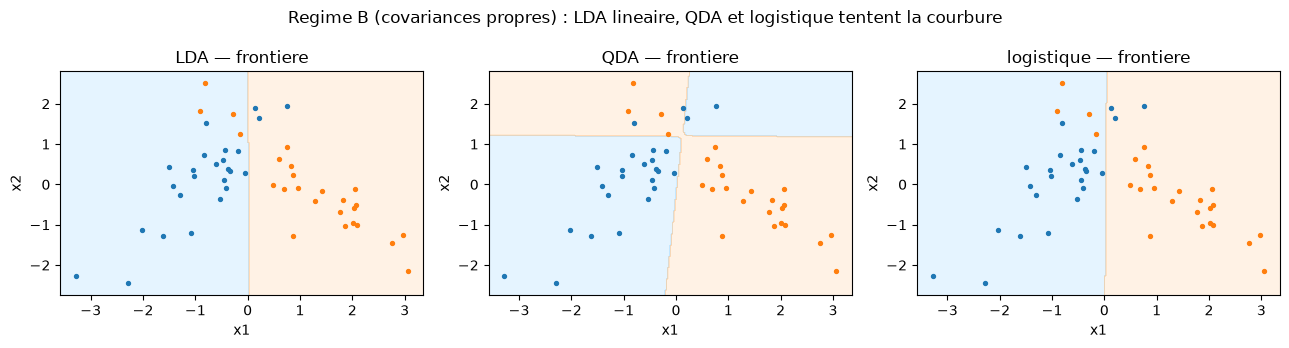

In [5]:
# 4.1 Frontières de décision sur le regime B (courbure visible)
from matplotlib.colors import ListedColormap
SEED = 42
XtrB, ytrB = make_pair(200, muB0, muB1, S_B0, S_B1, SEED)
XteB, yteB = make_pair(500, muB0, muB1, S_B0, S_B1, SEED + 1)
def plot_boundary(ax, model, X, y, title, steps=300):
    xmin, xmax = X[:,0].min()-0.3, X[:,0].max()+0.3
    ymin, ymax = X[:,1].min()-0.3, X[:,1].max()+0.3
    xx, yy = np.meshgrid(np.linspace(xmin,xmax,steps), np.linspace(ymin,ymax,steps))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(["#99d5ff","#ffcc99"]))
    ax.scatter(X[y==0,0], X[y==0,1], s=8, c="#1f77b4", label="classe 0")
    ax.scatter(X[y==1,0], X[y==1,1], s=8, c="#ff7f0e", label="classe 1")
    ax.set_title(title); ax.set_xlabel("x1"); ax.set_ylabel("x2")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
msub = {"LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis(),
        "logistique": LogisticRegression(max_iter=8000)}
for ax,(name,m) in zip(axes, msub.items()):
    m.fit(XtrB, ytrB)
    plot_boundary(ax, m, XteB[::20], yteB[::20], f"{name} — frontiere")
plt.suptitle("Regime B (covariances propres) : LDA lineaire, QDA et logistique tentent la courbure")
plt.tight_layout(); plt.show()


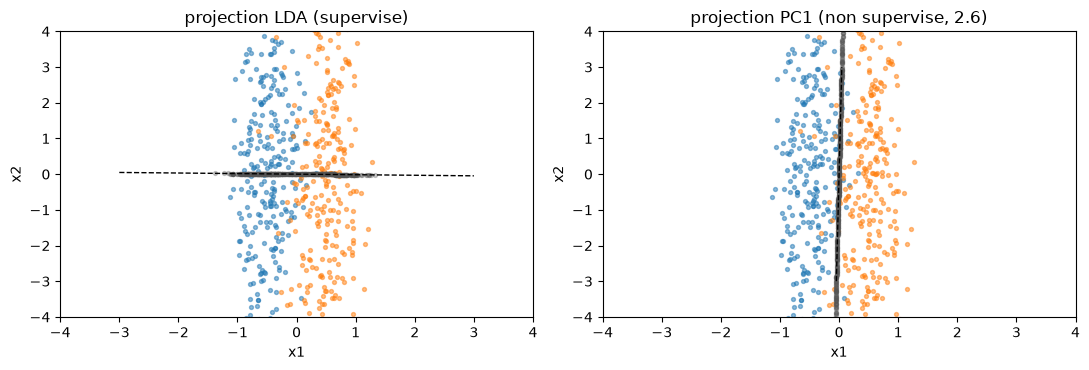

cos(w_LDA, w_PC1) = -0.0004
variance selon x1 = 0.35 | variance selon x2 = 9.73


In [6]:
# 4.2 Axe discriminant (supervise) vs axe de variance max (non supervise, cf 2.6)
# Jeu "cigar" : classes separees selon x1 (petite separation) mais variance enorme selon x2.
# -> la variance max (PCA) pointe x2, le discriminant (LDA) pointe x1. Ils divergent.
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SKLDA2
def cigar(n, seed):
    r = np.random.default_rng(seed)
    mu0, mu1 = np.array([-0.5, 0.0]), np.array([0.5, 0.0])
    S = np.array([[0.1, 0.0], [0.0, 10.0]])
    X0 = r.multivariate_normal(mu0, S, n); X1 = r.multivariate_normal(mu1, S, n)
    return np.vstack([X0, X1]), np.concatenate([np.zeros(n), np.ones(n)]).astype(int)
Xc, yc = cigar(300, 42)
lda = SKLDA2(n_components=1).fit(Xc, yc)
pca = PCA(n_components=2).fit(Xc)
w_lda = lda.coef_[0] / np.linalg.norm(lda.coef_[0])
w_pc1 = pca.components_[0]

def proj2d(X, w):
    t = X @ w
    return t[:, None] * w[None, :]   # projection sur la droite w

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, w, name in [(axes[0], w_lda, "projection LDA (supervise)"),
                    (axes[1], w_pc1, "projection PC1 (non supervise, 2.6)")]:
    ax.scatter(Xc[yc==0,0], Xc[yc==0,1], s=8, c="#1f77b4", alpha=0.5)
    ax.scatter(Xc[yc==1,0], Xc[yc==1,1], s=8, c="#ff7f0e", alpha=0.5)
    pts = proj2d(Xc, w)
    ax.scatter(pts[:,0], pts[:,1], s=8, c="#555555", alpha=0.3)
    ax.plot([-w[0]*3, w[0]*3], [-w[1]*3, w[1]*3], "k--", lw=1)
    ax.set_title(name); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_xlim(-4,4); ax.set_ylim(-4,4)
plt.tight_layout(); plt.show()
print("cos(w_LDA, w_PC1) =", round(float(np.dot(w_lda, w_pc1)), 4))
print("variance selon x1 =", round(float(Xc[:,0].var()), 2), "| variance selon x2 =", round(float(Xc[:,1].var()), 2))


### Lecture — la géométrie rend l'hypothèse visible

- **Frontières** (régime B) : LDA trace une **droite** (linéaire), QDA une **conique** qui épouse la courbure des classes, la logistique une droite aussi. La géométrie rend l'hypothèse de covariance **visible**.
- **Projection** (jeu « cigar » : classes séparées selon x1 mais variance énorme selon x2) : `cos(w_LDA, w_PC1) ≈ 0`. LDA projette sur l'axe qui **sépare** (x1) ; PC1 sur l'axe de **variance maximale** (x2, 96.5 % de la variance). Deux directions **orthogonales**. La projection supervisée (LDA) choisit l'axe discriminant ; la projection non supervisée (PCA, cf [2.6](2.6-Clustering-KMeans-PCA.ipynb)) choisit l'axe de variance. Quand le signal de classe est porté par une direction de **faible variance** (comme ici), les deux divergents — et c'est LDA qui sépare.


### 5. Calibration et matrices de confusion — pas accuracy seule

Deux modèles peuvent avoir **la même accuracy** mais des probabilités très différentes : l'un sera bien calibré (une prédiction à 70 % est correcte ~70 % du temps), l'autre non. [2.5](2.5-Biais-Variance-CV-ROC.ipynb) introduisait la courbe ROC ; ici on regarde la **fiabilité** (calibration) et la **matrice de confusion** — pas seulement le taux de bien classés.


modele      Brier   acc
LDA          0.1124  0.8313
QDA          0.0469  0.9250
logistique   0.1129  0.8313
NaiveBayes   0.1124  0.8375


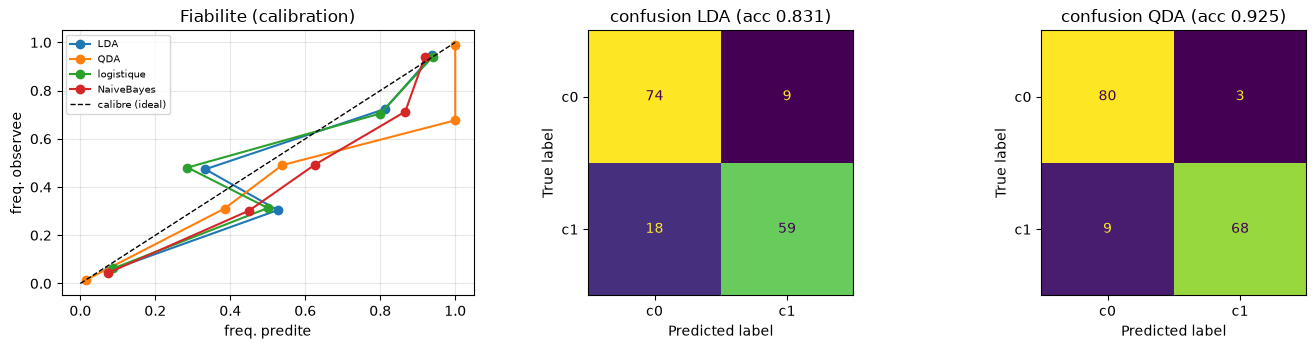

In [7]:
# 5.1 Reliability + Brier + confusion, sur un split commun (regime B)
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
Xtr, Xval, ytr, yval = train_test_split(XtrB, ytrB, test_size=0.4, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
def calibration(ax):
    for name, mk in models.items():
        m = mk().fit(Xtr, ytr)
        proba = m.predict_proba(Xval)[:,1]
        fop, tpv = calibration_curve(yval, proba, n_bins=6)
        ax.plot(fop, tpv, marker="o", label=name)
        if name=="LDA":
            # confusion pour LDA
            ax_c = None
    return
# Brier + confusion pour chaque modele
from sklearn.metrics import ConfusionMatrixDisplay
res_cal = {}
for name, mk in models.items():
    m = mk().fit(Xtr, ytr)
    p = m.predict_proba(Xval)[:, 1]
    res_cal[name] = (brier_score_loss(yval, p), accuracy_score(yval, m.predict(Xval)))
print("modele      Brier   acc")
for name, (b,a) in res_cal.items():
    print(f"{name:12s} {b:.4f}  {a:.4f}")

# courbes de calibration
ax = axes[0]
for name, mk in models.items():
    m = mk().fit(Xtr, ytr); p = m.predict_proba(Xval)[:,1]
    fop, tpv = calibration_curve(yval, p, n_bins=5)
    ax.plot(fop, tpv, marker="o", label=name)
ax.plot([0,1],[0,1], "k--", lw=1, label="calibre (ideal)")
ax.set_xlabel("freq. predite"); ax.set_ylabel("freq. observee"); ax.set_title("Fiabilite (calibration)")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# matrices de confusion pour deux cas
for ax, name in zip([axes[1], axes[2]], ["LDA", "QDA"]):
    m = models[name]().fit(Xtr, ytr)
    cm = confusion_matrix(yval, m.predict(Xval))
    ConfusionMatrixDisplay(cm, display_labels=["c0","c1"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"confusion {name} (acc {accuracy_score(yval, m.predict(Xval)):.3f})")
plt.tight_layout(); plt.show()


### Lecture — la calibration n'est pas l'accuracy

- **QDA** (Brier 0.0469, acc 0.9250) est **à la fois** le plus précis ET le mieux calibré : son hypothèse (Σ propres) colle au régime B, ses probabilités reflètent les fréquences réelles.
- **LDA** (0.1124, 0.8313) et **logistique** (0.1129, 0.8313) : même accuracy, tous deux moins précis et **mal calibrés** — la frontière fausse biaise leurs probabilités.
- **Naive Bayes** (acc 0.8375) : l'accuracy la plus haute des « mauvaises hypothèses » mais Brier 0.1124 (comme LDA) — **précis moyen, mal calibré**.
- L'accuracy seule ne dit rien de la **fiabilité des probabilités** : deux modèles peuvent partager 0.8313 d'accuracy et différer en calibration. C'est la courbe de fiabilité et le Brier qui le montrent.


### 6. Grande dimension, singularité, régularisation — le coût de QDA

QDA estime **une covariance complète par classe** : c'est `d(d+1)/2` paramètres par classe, contre `d` pour LDA (covariance partagée) et `d` pour Naive Bayes (diagonale). En dimension `d`, LDA a `O(d)` paramètres, QDA a `O(d²)`. Le coût explose — et dès que `n_c` devient du même ordre que `d`, `Σ_c` devient **singulière** (non inversible).


In [8]:
# 6.1 Diagnostic : a d et n fixes, QDA s'effondre quand d >= n_c
from sklearn.metrics import accuracy_score
d_list = [2, 5, 10, 20, 30]
n_tr = 30   # n par classe -> d >= n_c fait sauter QDA
def make_highdim(d, n_c, seed):
    r = np.random.default_rng(seed)
    mu0, mu1 = np.zeros(d), np.ones(d)
    S = np.eye(d) * 1.0
    X0 = r.multivariate_normal(mu0, S, n_c); X1 = r.multivariate_normal(mu1, S, n_c)
    return np.vstack([X0, X1]), np.concatenate([np.zeros(n_c), np.ones(n_c)]).astype(int)

# nb de parametres estimes (k=2 classes) : moyens 2d + covariance(s) + priors (k-1)
def p_lda(d): return 2*d + d*(d+1)//2 + 1          # 1 covariance partagee
def p_qda(d): return 2*d + d*(d+1) + 1             # 2 covariances propres
def p_nb(d):  return 2*d + 2*d + 1                 # moyennes + variances diagonales

print("d | n_par_cl | params LDA | params QDA | params NB | LDA acc | QDA acc | NB acc | QDA_cov_singulier")
for d in d_list:
    Xtr, ytr = make_highdim(d, n_tr, 42)
    Xte, yte = make_highdim(d, 500, 7)
    lda = LinearDiscriminantAnalysis().fit(Xtr, ytr)      # solveur par defaut
    nb = GaussianNB().fit(Xtr, ytr)
    try:
        qda = QuadraticDiscriminantAnalysis().fit(Xtr, ytr)
        qacc = accuracy_score(yte, qda.predict(Xte)); sing = False
    except Exception:
        qacc = float("nan"); sing = True
    print(f"{d:2d} | {n_tr:2d} | {p_lda(d):7d} | {p_qda(d):7d} | {p_nb(d):7d} | "
          f"{accuracy_score(yte, lda.predict(Xte)):.3f} | {qacc:.3f} | "
          f"{accuracy_score(yte, nb.predict(Xte)):.3f} | {sing}")


d | n_par_cl | params LDA | params QDA | params NB | LDA acc | QDA acc | NB acc | QDA_cov_singulier
 2 | 30 |       8 |      11 |       9 | 0.769 | 0.772 | 0.776 | False
 5 | 30 |      26 |      41 |      21 | 0.856 | 0.826 | 0.849 | False
10 | 30 |      76 |     131 |      41 | 0.910 | 0.900 | 0.927 | False
20 | 30 |     251 |     461 |      81 | 0.956 | 0.833 | 0.981 | False
30 | 30 |     526 |     991 |     121 | 0.975 | nan | 0.994 | True


### Lecture — le mur de la dimension

Le coût se lit dans le tableau :

- **Paramètres** (k=2 classes) : LDA ≈ d²/2 (cov partagée), QDA ≈ d² (deux covariances), NB ≈ 4d (diagonal). À d=30 : LDA 526, QDA 991, NB 121. **QDA est ~2× LDA**, Naive Bayes reste **linéaire**.
- **Accuracy** : d=2..10 → LDA/QDA/NB proches (0.77–0.93) ; à **d=20** QDA décroche (0.833 vs LDA 0.956, NB 0.981) ; à **d=30** QDA devient **nan** — sa covariance par classe est **singulière** (non inversible) — tandis que LDA 0.975 et NB 0.994 survivent.
- Le **mur** : dès que d rivalise avec n_c, la covariance par classe de QDA n'est plus inversible → effondrement. LDA (covariance partagée + solveur SVD) survit ; Naive Bayes (diagonal, 4d paramètres) est le plus robuste. C'est le **prix de la flexibilité** : la frontière quadratique coûte d² paramètres, et en grande dimension ce coût devient une **singularité**.


## Conclusion

Le modèle gaussien relie deux façons de décider :

- **Hypothèse de covariance partagée** → frontière **linéaire** (LDA), `O(d)` paramètres, robuste en petit `n`. C'est le bon modèle quand les classes sont **raisonnablement homoscédastiques**.
- **Hypothèse de covariances propres** → frontière **quadratique** (QDA), `O(d²)` paramètres, coûteux et fragile dès que `n_c` approche `d`. C'est le bon modèle quand la **forme** des classes diffère.
- **Naive Bayes** ([2.3b](2.3b-Naive-Bayes-Generatif.ipynb)) est le cas diagonal — encore plus restrictif, mais le plus économe.

La **frontière** est la signature visible de l'hypothèse, et la **projection discriminante** (LDA) sépare mieux que la projection de variance maximale ([2.6](2.6-Clustering-KMeans-PCA.ipynb)) quand la classe est ce qu'on veut séparer. Le bon choix n'est pas « le modèle qui a le plus de paramètres » mais **celui dont l'hypothèse de covariance colle aux données** — mesurable, pas raconté.


### Exercice 1 — implémenter le QDA de zéro

On généralise `MyLDA` en `MyQDA` : chaque classe garde sa **propre** covariance `Σ_c` et le terme quadratique `-1/2 log|Σ_c|` est **conservé** (il ne se simplifie plus). Écrire la version complète où `log P(c|x)` est calculé avec `Σ_c` (propre) **et** le terme `-1/2 log|Σ_c|`.


In [9]:
# Exercice 1 : QDA de zero (generaliser MyLDA)
class MyQDA:
    def fit(self, X, y):
        # Etape 1 : pour chaque classe, moyenne + covariance PROPRE
        self.classes = np.unique(y)
        self.means = {}
        self.cov = {}
        self.prior = {}
        for c in self.classes:
            Xc = X[y == c]
            self.means[c] = Xc.mean(axis=0)
            self.cov[c] = np.cov(Xc, rowvar=False) + 1e-9 * np.eye(X.shape[1])
            self.prior[c] = len(Xc) / len(y)
        return self

    def log_posterior(self, X):
        # Etape 2 : log P(c|x) = -1/2 log|Sigma_c| - 1/2 (x-mu_c)^T Sigma_c^-1 (x-mu_c) + log prior
        result = None  # TODO etudiant : calculer la matrice (n_classes, n)
        print("Exercice a completer")
        return result

    def predict(self, X):
        lp = self.log_posterior(X)
        if lp is None:
            return np.zeros(len(X), dtype=int)   # TODO etudiant : argmax de la matrice
        return self.classes[np.argmax(lp, axis=0)]


### Exercice 2 — trouver la frontière entre LDA et QDA

Faire varier la **taille du train** `n` (de 15 à 300) sur le régime B (covariances propres) et tracer l'accuracy de LDA vs QDA. Identifier le `n` à partir duquel QDA passe devant LDA.


In [10]:
# Exercice 2 : ou QDA depasse-t-il LDA quand n grandit ?
import numpy as np
# Etape 1 : reutiliser make_pair(muB0, muB1, S_B0, S_B1) sur une grille de n
# Etape 2 : pour chaque n, fit LDA et QDA sur un split commun, comparer l'accuracy test
# Etape 3 : imprimer le plus petit n ou QDA > LDA
result = None  # TODO etudiant
print("Exercice a completer")


Exercice a completer


### Exercice 3 — reconnaître le régime

Trois jeux de données simulés sont fournis. Pour chacun dire **quelle hypothèse de covariance** il illustre et **quel modèle** est attendu, puis le vérifier en fitant LDA et QDA.


In [11]:
# Exercice 3 : reconnaitre le regime de covariance
# (a) deux classes, meme dispersion, moyennes bien separees
# (b) deux classes, une etroite et une tres etalee, moyennes proches
# (c) trois classes formees en croissant
# Etape 1 : fit LDA et QDA sur chaque jeu
# Etape 2 : comparer les accuracies et nommer l'hypothese de covariance
# Etape 3 : conclure quel modele est attendu
result = None  # TODO etudiant
print("Exercice a completer")


Exercice a completer
